# Adagrad, RMSprop and Adam Optimization Algorithms



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

## Load Dataset

We use the MNIST handwritten-digit dataset, just as in the Momentum/NAG notebook.

Pixel values are normalized from `0–255` to `0–1`.


In [2]:
# LOAD DATASET

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


# Creating Models

We keep the same architecture used in the Momentum/NAG notebook:

- Flatten: `28 × 28 → 784`
- Dense: `128` neurons, ReLU
- Dense: `64` neurons, ReLU
- Output: `10` neurons, Softmax


In [3]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    return model


# 1. MODEL WITH ADAGRAD

In [4]:
model_adagrad = create_model()

optimizer_adagrad = tf.keras.optimizers.Adagrad(
    learning_rate=0.01
)

model_adagrad.compile(
    optimizer=optimizer_adagrad,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training using Adagrad...")

history_adagrad = model_adagrad.fit(
    x_train,
    y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.1
)


C:\Users\Shekhar Kumar\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training using Adagrad...
Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7471 - loss: 1.0179 - val_accuracy: 0.8915 - val_loss: 0.4395
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8812 - loss: 0.4353 - val_accuracy: 0.9140 - val_loss: 0.3171
Epoch 3/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8999 - loss: 0.3573 - val_accuracy: 0.9218 - val_loss: 0.2753
Epoch 4/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9094 - loss: 0.3199 - val_accuracy: 0.9283 - val_loss: 0.2526
Epoch 5/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9167 - loss: 0.2948 - val_accuracy: 0.9318 - val_loss: 0.2365
Epoch 6/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9220 - loss: 0.2749 - val_accuracy: 0.9367 - val_loss: 0.2206
Epoch 7/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9263 - loss: 0.2588 - val_accuracy: 0.9403 - val_loss: 0.2085
Epoch 8/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9299

# 2. MODEL WITH RMSPROP



In [5]:
model_rmsprop = create_model()

optimizer_rmsprop = tf.keras.optimizers.RMSprop(
    learning_rate=0.001,
    rho=0.9
)

model_rmsprop.compile(
    optimizer=optimizer_rmsprop,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training using RMSprop...")

history_rmsprop = model_rmsprop.fit(
    x_train,
    y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.1
)


Training using RMSprop...
Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8847 - loss: 0.4171 - val_accuracy: 0.9523 - val_loss: 0.1777
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9435 - loss: 0.1914 - val_accuracy: 0.9582 - val_loss: 0.1414
Epoch 3/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9589 - loss: 0.1355 - val_accuracy: 0.9715 - val_loss: 0.1019
Epoch 4/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9685 - loss: 0.1041 - val_accuracy: 0.9700 - val_loss: 0.1008
Epoch 5/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9749 - loss: 0.0831 - val_accuracy: 0.9752 - val_loss: 0.0838
Epoch 6/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9796 - loss: 0.0682 - val_accuracy: 0.9783 - val_loss: 0.0771
Epoch 7/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9833 - loss: 0.0570 - val_accuracy: 0.9768 - val_loss: 0.0743
Epoch 8/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9852 - 

# 3. MODEL WITH ADAM


In [6]:
model_adam = create_model()

optimizer_adam = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999
)

model_adam.compile(
    optimizer=optimizer_adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training using Adam...")

history_adam = model_adam.fit(
    x_train,
    y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.1
)


Training using Adam...
Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8770 - loss: 0.4496 - val_accuracy: 0.9540 - val_loss: 0.1754
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9485 - loss: 0.1784 - val_accuracy: 0.9633 - val_loss: 0.1319
Epoch 3/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9624 - loss: 0.1284 - val_accuracy: 0.9720 - val_loss: 0.1019
Epoch 4/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9708 - loss: 0.1009 - val_accuracy: 0.9733 - val_loss: 0.0912
Epoch 5/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9773 - loss: 0.0796 - val_accuracy: 0.9740 - val_loss: 0.0908
Epoch 6/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9807 - loss: 0.0670 - val_accuracy: 0.9743 - val_loss: 0.0854
Epoch 7/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9839 - loss: 0.0553 - val_accuracy: 0.9775 - val_loss: 0.0838
Epoch 8/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9867 - los

# Test All Three Models

Now we evaluate Adagrad, RMSprop and Adam on the same test dataset.


In [7]:
loss_adagrad, acc_adagrad = model_adagrad.evaluate(
    x_test,
    y_test,
    verbose=0
)

loss_rmsprop, acc_rmsprop = model_rmsprop.evaluate(
    x_test,
    y_test,
    verbose=0
)

loss_adam, acc_adam = model_adam.evaluate(
    x_test,
    y_test,
    verbose=0
)


# Print Results


In [8]:
print("Adagrad Accuracy:", acc_adagrad * 100, "%")
print("RMSprop Accuracy:", acc_rmsprop * 100, "%")
print("Adam Accuracy:", acc_adam * 100, "%")


Adagrad Accuracy: 95.89999914169312 %
RMSprop Accuracy: 97.89000153541565 %
Adam Accuracy: 97.57000207901001 %


# Compare Training and Validation Accuracy

This plot helps us see how quickly each optimizer learns and whether their validation performance differs.


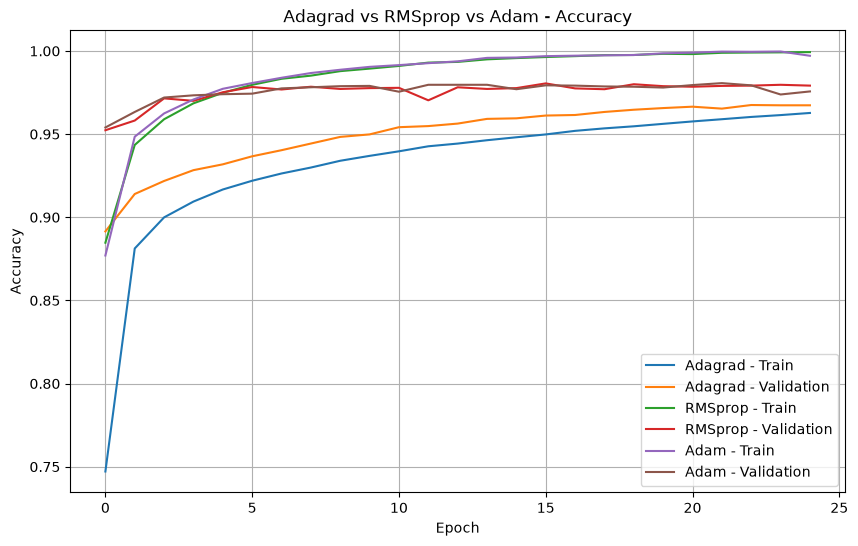

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(history_adagrad.history['accuracy'], label='Adagrad - Train')
plt.plot(history_adagrad.history['val_accuracy'], label='Adagrad - Validation')

plt.plot(history_rmsprop.history['accuracy'], label='RMSprop - Train')
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSprop - Validation')

plt.plot(history_adam.history['accuracy'], label='Adam - Train')
plt.plot(history_adam.history['val_accuracy'], label='Adam - Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Adagrad vs RMSprop vs Adam - Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Compare Training and Validation Loss


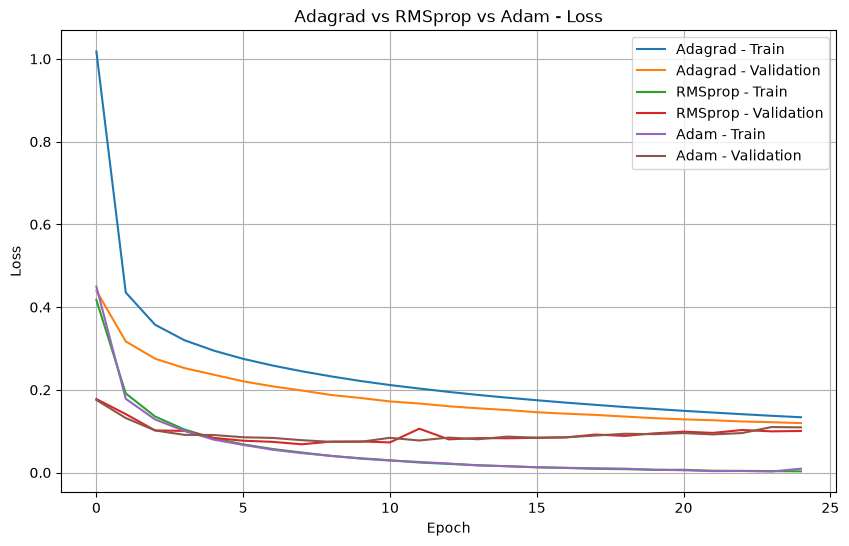

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(history_adagrad.history['loss'], label='Adagrad - Train')
plt.plot(history_adagrad.history['val_loss'], label='Adagrad - Validation')

plt.plot(history_rmsprop.history['loss'], label='RMSprop - Train')
plt.plot(history_rmsprop.history['val_loss'], label='RMSprop - Validation')

plt.plot(history_adam.history['loss'], label='Adam - Train')
plt.plot(history_adam.history['val_loss'], label='Adam - Validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adagrad vs RMSprop vs Adam - Loss')
plt.legend()
plt.grid(True)
plt.show()


# Final Comparison

We create a simple table containing test loss and test accuracy for all three optimizers.


In [11]:
results = {
    'Optimizer': ['Adagrad', 'RMSprop', 'Adam'],
    'Test Loss': [loss_adagrad, loss_rmsprop, loss_adam],
    'Test Accuracy (%)': [
        acc_adagrad * 100,
        acc_rmsprop * 100,
        acc_adam * 100
    ]
}

for i in range(len(results['Optimizer'])):
    print(
        f"{results['Optimizer'][i]:<10} | "
        f"Loss: {results['Test Loss'][i]:.4f} | "
        f"Accuracy: {results['Test Accuracy (%)'][i]:.2f}%"
    )


Adagrad    | Loss: 0.1405 | Accuracy: 95.90%
RMSprop    | Loss: 0.0956 | Accuracy: 97.89%
Adam       | Loss: 0.1106 | Accuracy: 97.57%


# Understanding the Difference

### Adagrad
- Adapts the learning rate for each parameter.
- Useful when parameters have very different update frequencies.
- Its accumulated squared gradients continually grow, so the effective learning rate can become very small.

### RMSprop
- Uses a moving average of squared gradients.
- Avoids the continuously shrinking learning-rate behavior of Adagrad.
- Often works well for neural-network training.

### Adam
- Combines momentum-like first-moment information with RMSprop-like second-moment information.
- Uses bias correction.
- Usually provides a strong practical baseline.




# Compare Final Validation Accuracy

This gives a quick visual comparison of the final validation accuracy after the last epoch.


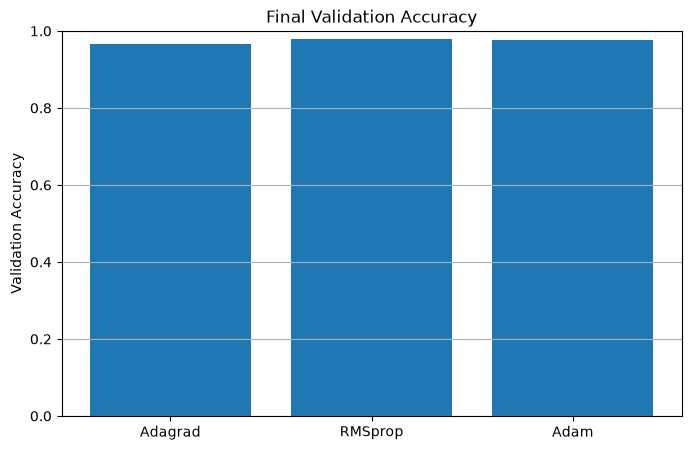

In [12]:
final_val_accuracy = [
    history_adagrad.history['val_accuracy'][-1],
    history_rmsprop.history['val_accuracy'][-1],
    history_adam.history['val_accuracy'][-1]
]

optimizers = ['Adagrad', 'RMSprop', 'Adam']

plt.figure(figsize=(8, 5))
plt.bar(optimizers, final_val_accuracy)

plt.ylabel('Validation Accuracy')
plt.title('Final Validation Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
